In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter

rmse = pd.read_csv('rmse_oaat.csv', index_col='epoch')
comm = pd.read_csv('commute_oaat.csv', index_col='epoch')


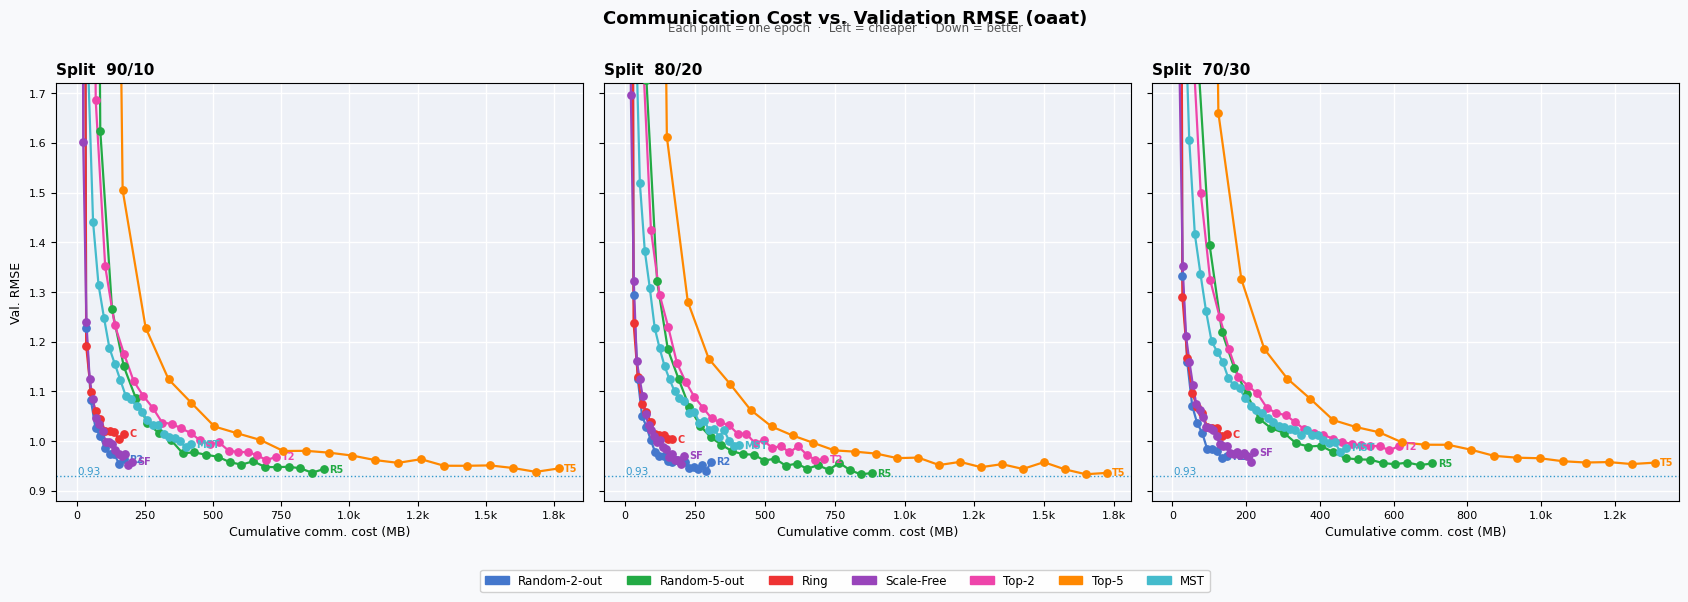

In [7]:

topologies = {
    'Random2out': ('Random-2-out', '#4477CC'),
    'Random5out': ('Random-5-out', '#22AA44'),
    'Cycle':      ('Ring',        '#EE3333'),
    'ScaleFree':  ('Scale-Free',   '#9944BB'),
    'Top2':       ('Top-2',        '#EE44AA'),
    'Top5':       ('Top-5',        '#FF8800'),
    'MST':        ('MST',          '#44BBCC'),
}
short_labels = {
    'Random2out': 'R2', 'Random5out': 'R5', 'Cycle': 'C',
    'ScaleFree': 'SF', 'Top2': 'T2', 'Top5': 'T5', 'MST': 'MST',
}
splits = ['90/10', '80/20', '70/30']
split_titles = ['Split  90/10', 'Split  80/20', 'Split  70/30']

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), sharey=True)
fig.patch.set_facecolor('#F8F9FB')

def xfmt(v, _):
    return f'{v/1000:.1f}k' if v >= 1000 else f'{int(v)}'

for ax, split, title in zip(axes, splits, split_titles):
    ax.set_facecolor('#EEF1F7')
    ax.grid(True, color='white', linewidth=1.0, zorder=0)

    for topo, (label, color) in topologies.items():
        col = f'{topo}_{split}'
        if col not in rmse.columns or col not in comm.columns:
            continue
        x = comm[col].dropna()
        y = rmse[col].dropna()
        idx = x.index.intersection(y.index)
        if len(idx) < 2:
            continue
        xv, yv = x[idx].values, y[idx].values

        ax.plot(xv, yv, color=color, linewidth=1.6, zorder=2)
        ax.scatter(xv, yv, color=color, s=28, zorder=3)

        # end-of-line label
        ax.annotate(short_labels[topo], xy=(xv[-1], yv[-1]),
                    xytext=(4, 0), textcoords='offset points',
                    fontsize=7, color=color, va='center', fontweight='bold')

    # 0.93 reference line
    ax.axhline(0.93, color='#3399CC', linewidth=1.0, linestyle=':', zorder=1)
    ax.text(2, 0.932, '0.93', color='#3399CC', fontsize=7.5)

    ax.set_title(title, fontsize=11, fontweight='bold', loc='left', pad=6)
    ax.set_xlabel('Cumulative comm. cost (MB)', fontsize=9)
    if ax == axes[0]:
        ax.set_ylabel('Val. RMSE', fontsize=9)
    ax.set_ylim(0.88, 1.72)
    ax.tick_params(labelsize=8)
    ax.xaxis.set_major_formatter(FuncFormatter(xfmt))

fig.suptitle('Communication Cost vs. Validation RMSE (oaat)', fontsize=13, fontweight='bold', y=1.01)
fig.text(0.5, 0.97, 'Each point = one epoch  ·  Left = cheaper  ·  Down = better',
         ha='center', fontsize=8.5, color='#555555')

patches = [mpatches.Patch(color=c, label=l) for _, (l, c) in topologies.items()]
fig.legend(handles=patches, ncol=7, loc='lower center',
           bbox_to_anchor=(0.5, -0.06), fontsize=8.5,
           frameon=True, framealpha=0.9, edgecolor='#cccccc')

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.savefig('rmse_vs_commcost_3panel.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()